In [ ]:
#1. LOAD THE PACKAGES
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')

RANDOM_STATE = 55 #we will pass it to every sklearn call so we ensure reproducibility

In [ ]:
#Training a ML model to assist diagnosing CVDs(possible heart disease)

In [22]:
#load dataset
df = pd.read_csv('heart.csv')

In [23]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [24]:
df.shape

(918, 12)

In [ ]:
#2. ONE-HOT CODING USING PANDAS
#one hot encoding using pandas
# remove the binary variables
cat_variables = ['Sex',
                 'ChestPainType',
                 'RestingECG',
                 'ExerciseAngina',
                 'ST_Slope']

In [26]:
#replace columns with one-hot encoded values and keep the columns outside `columns`
# argument as it is
df = pd.get_dummies(data = df,
                    prefix=cat_variables,
                    columns=cat_variables)

In [27]:
df.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [30]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138,214,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150,195,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [29]:
df.shape

(918, 21)

In [ ]:
#choose variables that will be the input features of the model
#the target is `HeartDisease`
#all other variables are features that can be used to predict `HeartDisease`
features = [x for x in df.columns if x not in 'HeartDisease']   #removing out target variable

In [32]:
print(len(features))

20


In [ ]:
#3. SPLITTING THE DATASET
#spliting the dataset into `train` and `test` sets
help(train_test_split) #checking the arguments of the `train_test_split` function

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(df[features], df['HeartDisease'],
                                                  train_size=0.8, random_state=RANDOM_STATE )

#we will keep the shuffle = True since our dataset has not any time dependency


In [37]:
#view the train and test sets
print(f'Train Samples: {len(X_train)}')
print(f'Validation Samples: {len(X_val)}')
print(f'Target Proportion: {sum(y_train) / len(y_train):.4f}')

Train Samples: 734
Validation Samples: 184
Target Proportion: 0.5518


In [ ]:
#4. BUILDING THE MODELS
#Decision Tree
''' min_samples_split: The minimum number of samples required to split an internal node.
        Choosing a higher min_samples_split can reduce the number of splits and may help to reduce overfitting.
    max_depth: The maximum depth of the tree.
        Choosing a lower max_depth can reduce the number of splits and may help to reduce overfitting.
'''

In [40]:
min_samples_split_list = [2,10,30,50,100,200,300,700] #if the number is an int, then it is the actual quantity
                    # of samples
max_depth_list = [1,2,3,4,8,16,32,64,None] #`None` means that there is no depth limit

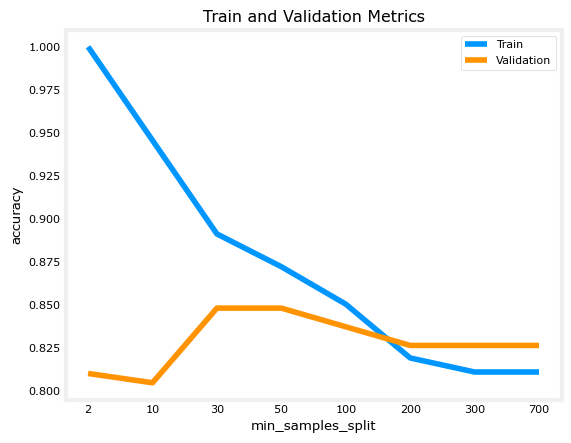

In [41]:
accuracy_list_train = []
accuracy_list_val = []
for min_samples_split in min_samples_split_list:
    #you can fit the model at the same time you define it, becasuse the fit function returns the fitted estimator
    model = DecisionTreeClassifier(min_samples_split=min_samples_split,
                                   random_state=RANDOM_STATE).fit(X_train, y_train)
    
    predictions_train = model.predict(X_train)  # The predicted values for the train dataset
    predictions_val = model.predict(X_val)  #The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train, y_train)
    accuracy_val = accuracy_score(predictions_val, y_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train and Validation Metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks=range(len(min_samples_split_list)), labels=min_samples_split_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train', 'Validation'])



In [ ]:
#observation - increase in the number of min_samples_split reduces overfitting

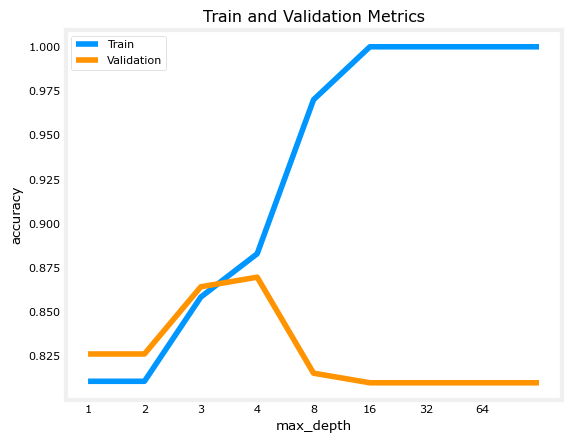

In [44]:
#maximum depth of a tree
accuracy_list_train = []
accuracy_list_val =[]
for max_depth in max_depth_list:
    #you can fit the model at teg same time you define it, cos the fit function returns the fitted estimator
    model = DecisionTreeClassifier(max_depth=max_depth,
                                   random_state=RANDOM_STATE).fit(X_train, y_train)
    predictions_train = model.predict(X_train) #The predicted values for the train dataset
    predictions_val = model.predict(X_val) #The predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train, y_train)
    accuracy_val = accuracy_score(predictions_val, y_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train and Validation Metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(max_depth_list)), labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train', 'Validation'])

In [ ]:
#observation:
# reducing max_depth from 8 to 4 increases validation accuracy closer to training accuracy, 
#   while significantly reducing training accuracy
#  Validation accuracy reaches the highest at tree_depth=4
# #When depth is <3, both training and validation accuracy decreases. (tree can't make enough
# splits to distinguish positives from negatives (the model is underfitting the training set))
#when max_depth is too high >=5, validation accuracy decreases, while training accuracy increases - 
# ( the model is overfitiing to training set)
# The best values for these two hyper-parameters for our model will be:
#  `max_depth = 4
# min_samples_split = 50`


In [46]:
#implement the above
decision_tree_model = DecisionTreeClassifier(min_samples_split=50,
                                            max_depth= 3,
                                            random_state=RANDOM_STATE).fit(X_train, y_train)

In [48]:
print(f'Metrics train: \n\tAccuracy Score: {accuracy_score(decision_tree_model.predict(X_train),y_train):.4f}')
print(f'Metrics Validation: \n\tAccuracy Score: {accuracy_score(decision_tree_model.predict(X_val), y_val):.4f}')

Metrics train: 
	Accuracy Score: 0.8583
Metrics Validation: 
	Accuracy Score: 0.8641


In [ ]:
#Random Forest
#Additional hyperparameter for random forest is `n_estimators` which is the number of decision
# trees that make up the random forest

In [50]:
min_samples_split = [2,10,30,50,100,200,300,700] #if the number is an integer, then it is the actual quantity
#  of samples, if it is a float, them it is the % of the dataset
max_depth_list = [2, 4,8,16,23,64,None]  #
n_estimators_list = [10,50,100,500]


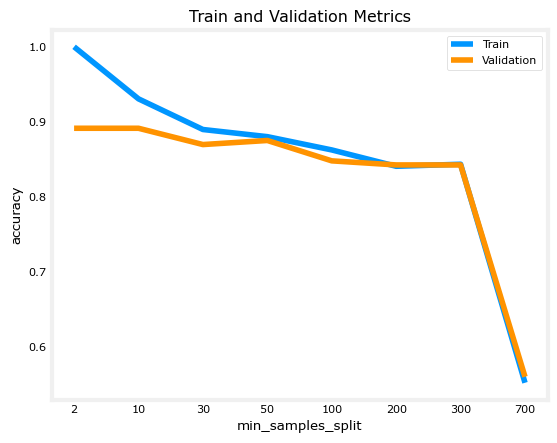

In [51]:
accuracy_list_train = []
accuracy_list_val = []
for min_samples_split in min_samples_split_list:
    #you can fit the model at the same time you define it, because the fit function returns the fitted estimator
    model = RandomForestClassifier(min_samples_split=min_samples_split,
                                   random_state=RANDOM_STATE).fit(X_train, y_train)
    predictions_train = model.predict(X_train) #the predicted values for the train dataset
    predictions_val = model.predict(X_val) #the predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train, y_train)
    accuracy_val = accuracy_score(predictions_val,y_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train and Validation Metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks = range(len(min_samples_split_list)), labels=min_samples_split_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train', 'Validation'])

In [ ]:
#observation
# The validation accuracy for split=2 and 10 are the same
# In the latter the difference in trianing and val sets reduces, showing less overfitting

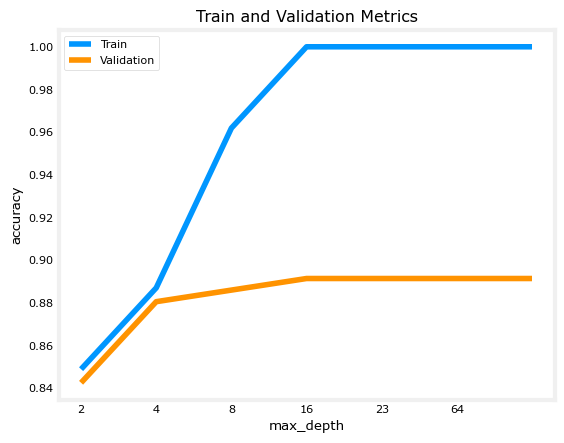

In [52]:
#for max-depth
accuracy_list_train = []
accuracy_list_val = []

for max_depth in max_depth_list:
    #you can fit the model at the same time you define it cos the fit function returns the fitted estimator
    model = RandomForestClassifier(max_depth=max_depth,
                                   random_state=RANDOM_STATE).fit(X_train, y_train)
    predictions_train = model.predict(X_train) # the predicted values for the train dataset
    predictions_val = model.predict(X_val) # the predicted values for the test dataset
    accuracy_train = accuracy_score(predictions_train, y_train)
    accuracy_val = accuracy_score(predictions_val, y_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)


plt.title('Train and Validation Metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks=range(len(max_depth_list)), labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train', 'Validation'])

In [ ]:
#observation
#Accuracy for both training and validation increases as the depth increases

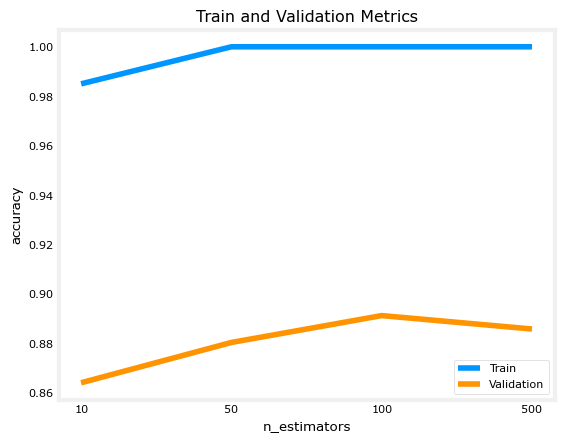

In [53]:
accuracy_list_train = []
accuracy_list_val = []
for n_estimators in n_estimators_list:
    #you can fit the model at the same time you define it cos the fit function returns the fitted estimator
    model = RandomForestClassifier(n_estimators=n_estimators,
                                   random_state=RANDOM_STATE).fit(X_train, y_train)
    predictions_train = model.predict(X_train)  #the predicted values for the teain dataset
    predictions_val = model.predict(X_val) #the predcited values for the test dataset
    accuracy_train = accuracy_score(predictions_train,y_train)
    accuracy_val = accuracy_score(predictions_val, y_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train and Validation Metrics')
plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.xticks(ticks=range(len(n_estimators_list)), labels=n_estimators_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train', 'Validation'])

In [ ]:
#Lets fit a random forest with the following parameters:
# max_depth: 16
# min_samples_split: 10
# n_estimators: 100

In [54]:
random_forest_model = RandomForestClassifier(n_estimators=100,
                                             max_depth=16,
                                             min_samples_split=10).fit(X_train, y_train)

In [62]:
print(f'Metrics train:\n\tAccuracy Score: {accuracy_score(random_forest_model.predict(X_train), y_train):.4f}\nMetrics Test:\n\tAccuracy Score: {accuracy_score(random_forest_model.predict(X_val),y_val):.4f}')

Metrics train:
	Accuracy Score: 0.9373
Metrics Test:
	Accuracy Score: 0.8913


In [ ]:
#XGBoost - TGradient Boosting Model
#Trains several trees that fit one after the other to minimize the error
''' 
How XGBoost works:
The model has the same parameters as a decision tree, plus the learning rate.
    The learning rate is the size of the step on the Gradient Descent method that 
     the XGBoost uses internally to minimize the error on each train step.
    On each iteration, it measures the cost (or evaluation metric) on the evaluation datasets.
    Once the cost (or metric) stops decreasing for a number of rounds (called early_stopping_rounds),
      the training will stop.
    More iterations lead to more estimators, and more estimators can result in overfitting.
    By stopping once the validation metric no longer improves, we can limit the number
      of estimators created, and reduce overfitting.
    '''


In [63]:
n = int(len(X_train)*0.8)  #lets use 80% to train  and 20% to evaluate


In [65]:
X_train_fit, X_train_eval, y_train_fit, y_train_eval = X_train[:n], X_train[n:], y_train[:n], y_train[n:]


In [ ]:
#we can set a large number of estimators cos we can stop if the cost function stops decreasing
'''
eval_set = [(X_train_eval,y_train_eval)]:Here we must pass a list to the eval_set, because you can have 
several different tuples ov eval sets.
early_stopping_rounds: This parameter helps to stop the model training if its evaluation metric is 
no longer improving on the validation set. It's set to 10

The model keeps track of the round with the best performance (lowest evaluation metric). For example, 
  let's say round 16 has the lowest evaluation metric so far.
Each successive round's evaluation metric is compared to the best metric. If the model goes 10 rounds
  where none have a better metric than the best one, then the model stops training.
The model is returned at its last state when training terminated, not its state during the best round. For example, 
 if the model stops at round 26, but the best round was 16, the model's training state at round 26
   is returned, not round 16.
Note that this is different from returning the model's "best" state (from when the evaluation metric was the lowest).
'''

In [67]:
xgb_model = XGBClassifier(n_estimators=500, learning_rate = 0.1, verbosity = 1, random_state=RANDOM_STATE, early_stopping_rounds = 10)
xgb_model.fit(X_train_fit, y_train_fit, eval_set=[(X_train_eval, y_train_eval)])

[0]	validation_0-logloss:0.63301
[1]	validation_0-logloss:0.59553
[2]	validation_0-logloss:0.56612
[3]	validation_0-logloss:0.54186
[4]	validation_0-logloss:0.52348
[5]	validation_0-logloss:0.50610
[6]	validation_0-logloss:0.49371
[7]	validation_0-logloss:0.48365
[8]	validation_0-logloss:0.47321
[9]	validation_0-logloss:0.46537
[10]	validation_0-logloss:0.45999
[11]	validation_0-logloss:0.45620
[12]	validation_0-logloss:0.45482
[13]	validation_0-logloss:0.44974
[14]	validation_0-logloss:0.44494
[15]	validation_0-logloss:0.44072
[16]	validation_0-logloss:0.44078
[17]	validation_0-logloss:0.43935
[18]	validation_0-logloss:0.44206
[19]	validation_0-logloss:0.44536
[20]	validation_0-logloss:0.44321
[21]	validation_0-logloss:0.44310
[22]	validation_0-logloss:0.44419
[23]	validation_0-logloss:0.44797
[24]	validation_0-logloss:0.44843
[25]	validation_0-logloss:0.45337
[26]	validation_0-logloss:0.45206
[27]	validation_0-logloss:0.45435


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#Note: Pass the `early_stopping_rounds=10` parameter to the `XGBClassifier` and not the `fit` method 

In [68]:
#lets view the round of training with the best perfomance
xgb_model.best_iteration

17

In [ ]:
#Observation - The best round of training was round 17 with a log loss of 4.3935
# The following trining rounds the log loss was higher than this

In [69]:
print(f'Metrics train:\n\tAccuracy Score: {accuracy_score(xgb_model.predict(X_train),y_train):.4f}\nMetrics Test:\n\tAccuracy Score: {accuracy_score(xgb_model.predict(X_val),y_val):.4f}')

Metrics train:
	Accuracy Score: 0.9319
Metrics Test:
	Accuracy Score: 0.8533
